In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive/Electricity_Forecasting')

['continuous dataset.csv.zip', 'data']

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Electricity_Forecasting/continuous dataset.csv.zip"
extract_path = "/content/drive/MyDrive/Electricity_Forecasting/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['continuous dataset.csv']


In [ ]:
import pandas as pd

data_path = "/content/drive/MyDrive/Electricity_Forecasting/data/continuous dataset.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 48048
Columns: 17


In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Column names:
['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school']

First 5 rows:


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [ ]:
print("DATA INFORMATION")
df.info()

print("\nMISSING VALUES")
print(df.isnull().sum())

DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48048 entries, 0 to 48047
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    48048 non-null  object 
 1   nat_demand  48048 non-null  float64
 2   T2M_toc     48048 non-null  float64
 3   QV2M_toc    48048 non-null  float64
 4   TQL_toc     48048 non-null  float64
 5   W2M_toc     48048 non-null  float64
 6   T2M_san     48048 non-null  float64
 7   QV2M_san    48048 non-null  float64
 8   TQL_san     48048 non-null  float64
 9   W2M_san     48048 non-null  float64
 10  T2M_dav     48048 non-null  float64
 11  QV2M_dav    48048 non-null  float64
 12  TQL_dav     48048 non-null  float64
 13  W2M_dav     48048 non-null  float64
 14  Holiday_ID  48048 non-null  int64  
 15  holiday     48048 non-null  int64  
 16  school      48048 non-null  int64  
dtypes: float64(13), int64(3), object(1)
memory usage: 6.2+ MB

MISSING VALUES
datetime      0


In [ ]:
df_clean = df.copy()

df_clean['datetime'] = pd.to_datetime(df_clean['datetime'])

df_clean = df_clean.sort_values('datetime').reset_index(drop=True)

print("Duplicate rows:", df_clean.duplicated().sum())

print("Start date:", df_clean['datetime'].min())
print("End date:", df_clean['datetime'].max())

print("\nData types:")
print(df_clean.dtypes)

Duplicate rows: 0
Start date: 2015-01-03 01:00:00
End date: 2020-06-27 00:00:00

Data types:
datetime      datetime64[ns]
nat_demand           float64
T2M_toc              float64
QV2M_toc             float64
TQL_toc              float64
W2M_toc              float64
T2M_san              float64
QV2M_san             float64
TQL_san              float64
W2M_san              float64
T2M_dav              float64
QV2M_dav             float64
TQL_dav              float64
W2M_dav              float64
Holiday_ID             int64
holiday                int64
school                 int64
dtype: object


In [ ]:
df_clean['year'] = df_clean['datetime'].dt.year
df_clean['month'] = df_clean['datetime'].dt.month
df_clean['day'] = df_clean['datetime'].dt.day
df_clean['hour'] = df_clean['datetime'].dt.hour
df_clean['day_of_week'] = df_clean['datetime'].dt.dayofweek


df_clean['weekend'] = (df_clean['day_of_week'] >= 5).astype(int)

print("Time features created successfully!")

print("\nNew columns:")
print(df_clean[['datetime', 'year', 'month', 'day', 'hour',
                'day_of_week', 'weekend']].head(10))

Time features created successfully!

New columns:
             datetime  year  month  day  hour  day_of_week  weekend
0 2015-01-03 01:00:00  2015      1    3     1            5        1
1 2015-01-03 02:00:00  2015      1    3     2            5        1
2 2015-01-03 03:00:00  2015      1    3     3            5        1
3 2015-01-03 04:00:00  2015      1    3     4            5        1
4 2015-01-03 05:00:00  2015      1    3     5            5        1
5 2015-01-03 06:00:00  2015      1    3     6            5        1
6 2015-01-03 07:00:00  2015      1    3     7            5        1
7 2015-01-03 08:00:00  2015      1    3     8            5        1
8 2015-01-03 09:00:00  2015      1    3     9            5        1
9 2015-01-03 10:00:00  2015      1    3    10            5        1


In [ ]:
print("Electricity Demand Statistics")
print(df_clean['nat_demand'].describe())

Electricity Demand Statistics
count    48048.000000
mean      1182.868647
std        192.068896
min         85.192500
25%       1020.056900
50%       1168.427700
75%       1327.563950
max       1754.882000
Name: nat_demand, dtype: float64


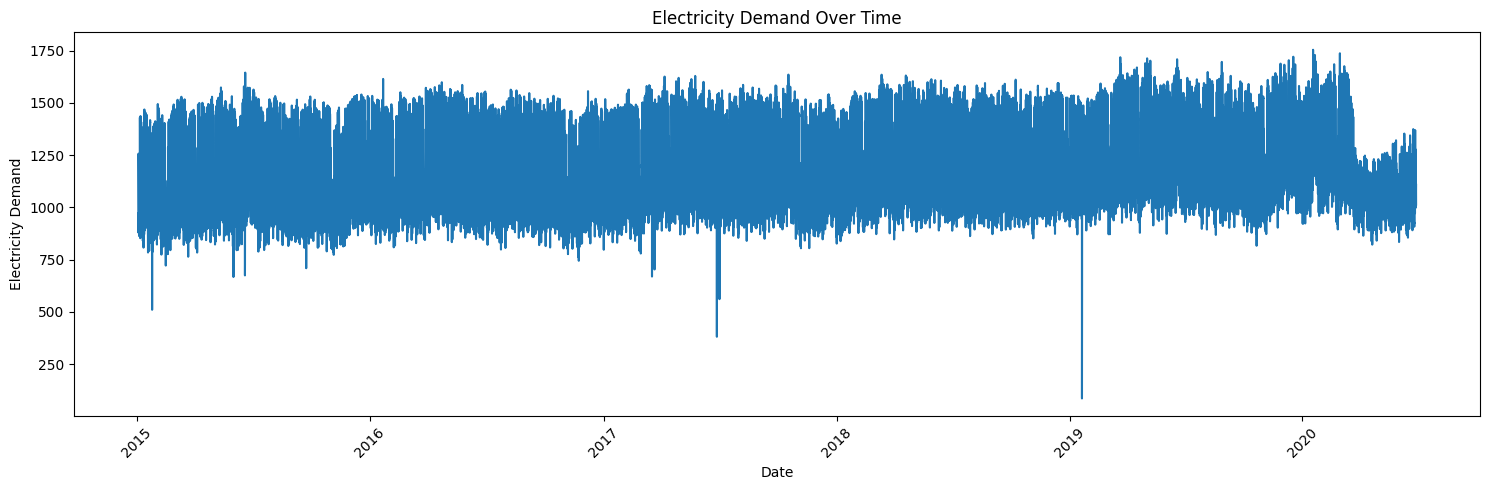

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(df_clean['datetime'], df_clean['nat_demand'])

plt.title('Electricity Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Electricity Demand')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
hourly_demand = df_clean.groupby('hour')['nat_demand'].mean()

print(hourly_demand)

hour
0     1050.036981
1     1011.019268
2      981.214835
3      959.791703
4      949.916913
5      962.834127
6      961.303967
7     1057.468187
8     1198.552073
9     1281.320332
10    1349.027937
11    1379.593048
12    1373.836615
13    1384.926445
14    1379.905136
15    1349.449667
16    1291.046193
17    1217.707377
18    1241.345821
19    1275.185046
20    1249.430751
21    1214.741156
22    1164.429552
23    1104.764404
Name: nat_demand, dtype: float64


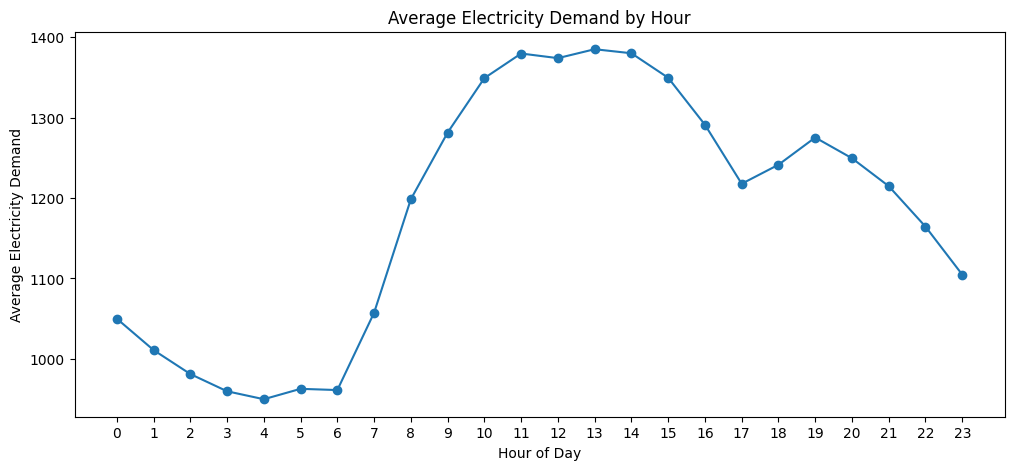

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(hourly_demand.index, hourly_demand.values, marker='o')

plt.title('Average Electricity Demand by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Electricity Demand')
plt.xticks(range(24))
plt.grid(False)

plt.show()

In [ ]:
weekend_demand = df_clean.groupby('weekend')['nat_demand'].mean()

print(weekend_demand)

weekend
0    1216.838317
1    1097.944472
Name: nat_demand, dtype: float64


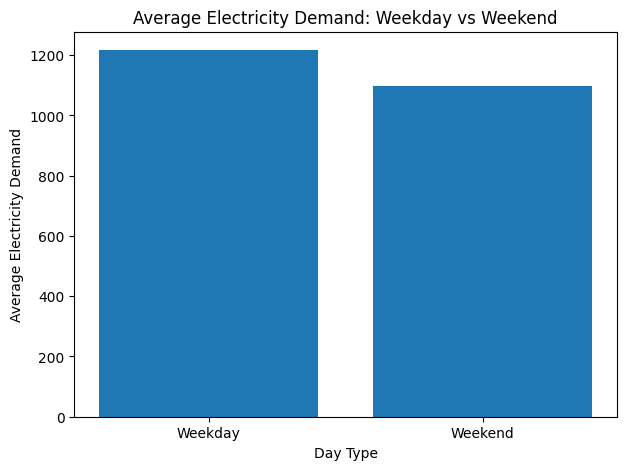

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(['Weekday', 'Weekend'], weekend_demand.values)

plt.title('Average Electricity Demand: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Average Electricity Demand')

plt.show()

In [ ]:
monthly_demand = df_clean.groupby('month')['nat_demand'].mean()

print(monthly_demand)

month
1     1167.247461
2     1175.027566
3     1192.545004
4     1187.815224
5     1187.367029
6     1191.606116
7     1182.465384
8     1189.930390
9     1180.768483
10    1183.070968
11    1148.642422
12    1205.624270
Name: nat_demand, dtype: float64


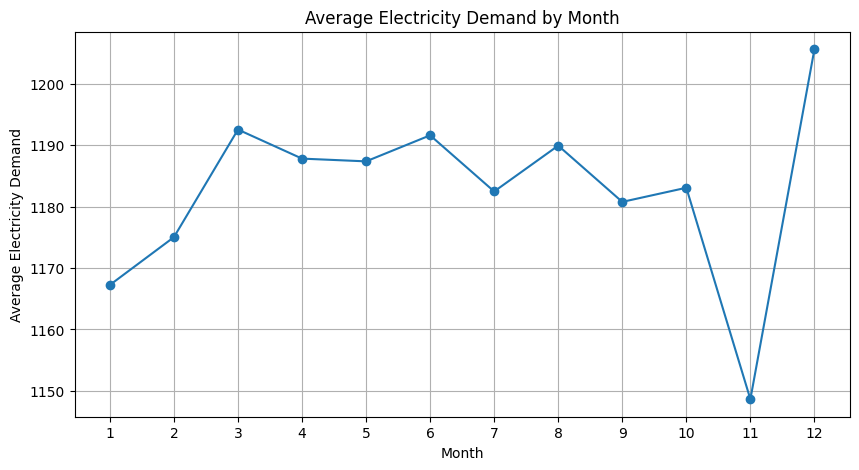

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(monthly_demand.index, monthly_demand.values, marker='o')

plt.title('Average Electricity Demand by Month')
plt.xlabel('Month')
plt.ylabel('Average Electricity Demand')
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

In [ ]:
holiday_demand = df_clean.groupby('holiday')['nat_demand'].mean()

print(holiday_demand)

holiday
0    1191.115235
1    1060.086115
Name: nat_demand, dtype: float64


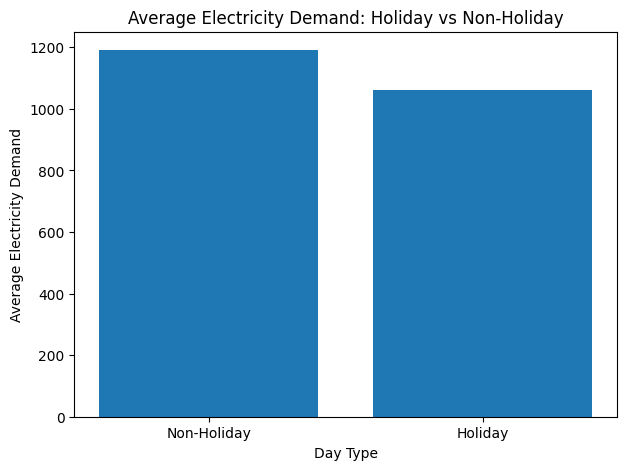

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(['Non-Holiday', 'Holiday'], holiday_demand.values)

plt.title('Average Electricity Demand: Holiday vs Non-Holiday')
plt.xlabel('Day Type')
plt.ylabel('Average Electricity Demand')

plt.show()

In [ ]:
school_demand = df_clean.groupby('school')['nat_demand'].mean()

print(school_demand)

school
0    1170.292530
1    1187.572329
Name: nat_demand, dtype: float64


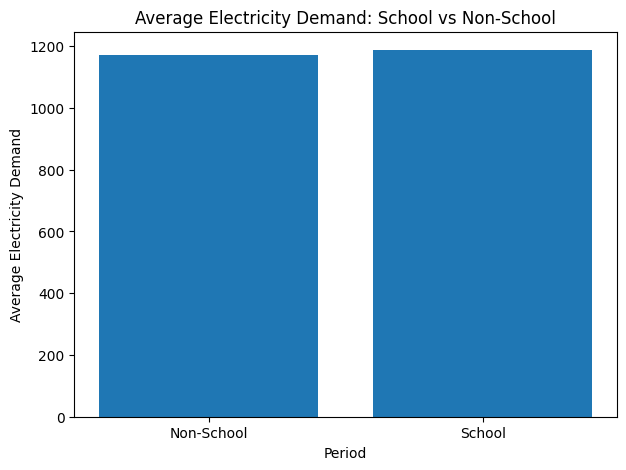

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(['Non-School', 'School'], school_demand.values)

plt.title('Average Electricity Demand: School vs Non-School')
plt.xlabel('Period')
plt.ylabel('Average Electricity Demand')

plt.show()

In [ ]:
weather_columns = [
    col for col in df_clean.columns
    if col not in [
        'datetime', 'nat_demand',
        'Holiday_ID', 'holiday', 'school',
        'year', 'month', 'day', 'hour',
        'day_of_week', 'weekend'
    ]
]

print("Weather-related columns:")
print(weather_columns)

Weather-related columns:
['T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav']


In [ ]:
weather_correlation = df_clean[weather_columns + ['nat_demand']].corr()['nat_demand']

weather_correlation = weather_correlation.sort_values(ascending=False)

print("Correlation with electricity demand:")
print(weather_correlation)

Correlation with electricity demand:
nat_demand    1.000000
T2M_toc       0.652811
T2M_dav       0.648279
T2M_san       0.627024
W2M_san       0.191796
TQL_san       0.119038
W2M_toc       0.098435
TQL_toc       0.073109
TQL_dav       0.042037
QV2M_san      0.022172
QV2M_dav     -0.002117
QV2M_toc     -0.036706
W2M_dav      -0.054802
Name: nat_demand, dtype: float64


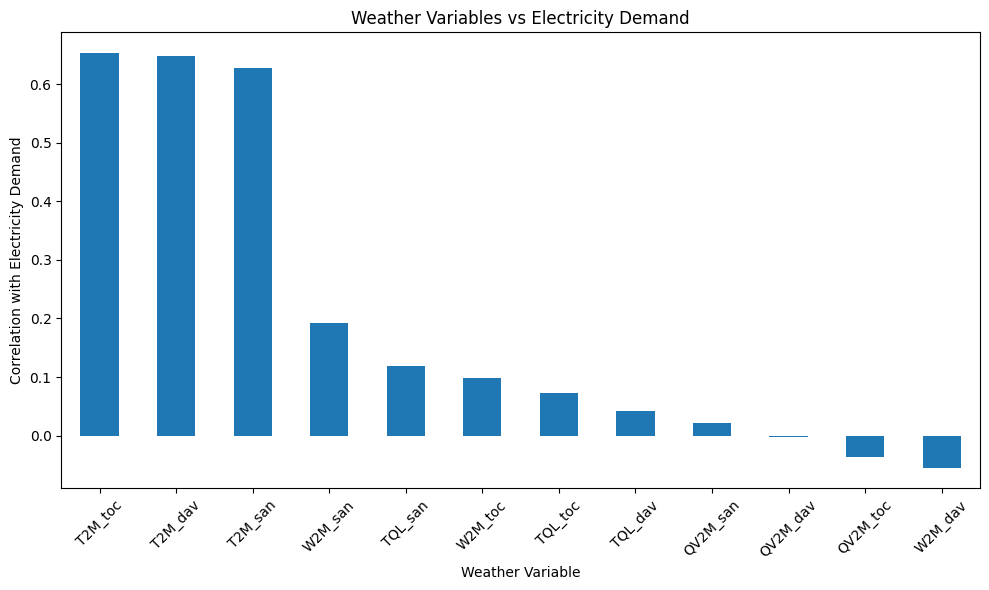

In [ ]:
plt.figure(figsize=(10, 6))

weather_correlation.drop('nat_demand').plot(kind='bar')

plt.title('Weather Variables vs Electricity Demand')
plt.xlabel('Weather Variable')
plt.ylabel('Correlation with Electricity Demand')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
df_clean['demand_lag_1'] = df_clean['nat_demand'].shift(1)
df_clean['demand_lag_24'] = df_clean['nat_demand'].shift(24)
df_clean['demand_lag_168'] = df_clean['nat_demand'].shift(168)

print("Lag features created successfully!")

display(df_clean[['datetime', 'nat_demand','demand_lag_1','demand_lag_24','demand_lag_168']].head(180))

Lag features created successfully!


,datetime,nat_demand,demand_lag_1,demand_lag_24,demand_lag_168
0,2015-01-03 01:00:00,970.3450,NaN,NaN,NaN
1,2015-01-03 02:00:00,912.1755,970.3450,NaN,NaN
2,2015-01-03 03:00:00,900.2688,912.1755,NaN,NaN
3,2015-01-03 04:00:00,889.9538,900.2688,NaN,NaN
4,2015-01-03 05:00:00,893.6865,889.9538,NaN,NaN
...,...,...,...,...,...
175,2015-01-10 08:00:00,1021.6720,897.8229,953.5700,1048.9720
176,2015-01-10 09:00:00,1108.9439,1021.6720,1006.9689,1167.9074
177,2015-01-10 10:00:00,1165.4756,1108.9439,1058.0176,1257.5069
178,2015-01-10 11:00:00,1179.0630,1165.4756,1088.0395,1254.5830


In [ ]:
df_clean['rolling_mean_24'] = (df_clean['nat_demand'].shift(1).rolling(window=24).mean())

df_clean['rolling_mean_168'] = (df_clean['nat_demand'].shift(1).rolling(window=168).mean())

print("Rolling average features created successfully!")

display(df_clean[['datetime','nat_demand','rolling_mean_24','rolling_mean_168']].head(180))

Rolling average features created successfully!


,datetime,nat_demand,rolling_mean_24,rolling_mean_168
0,2015-01-03 01:00:00,970.3450,NaN,NaN
1,2015-01-03 02:00:00,912.1755,NaN,NaN
2,2015-01-03 03:00:00,900.2688,NaN,NaN
3,2015-01-03 04:00:00,889.9538,NaN,NaN
4,2015-01-03 05:00:00,893.6865,NaN,NaN
...,...,...,...,...
175,2015-01-10 08:00:00,1021.6720,989.678383,1090.107536
176,2015-01-10 09:00:00,1108.9439,992.515967,1089.945036
177,2015-01-10 10:00:00,1165.4756,996.764925,1089.594063
178,2015-01-10 11:00:00,1179.0630,1001.242342,1089.046258


In [ ]:
print("Missing values after feature engineering:")
print(df_clean.isnull().sum())

Missing values after feature engineering:
datetime              0
nat_demand            0
T2M_toc               0
QV2M_toc              0
TQL_toc               0
W2M_toc               0
T2M_san               0
QV2M_san              0
TQL_san               0
W2M_san               0
T2M_dav               0
QV2M_dav              0
TQL_dav               0
W2M_dav               0
Holiday_ID            0
holiday               0
school                0
year                  0
month                 0
day                   0
hour                  0
day_of_week           0
weekend               0
demand_lag_1          1
demand_lag_24        24
demand_lag_168      168
rolling_mean_24      24
rolling_mean_168    168
dtype: int64


In [ ]:
df_clean = df_clean.dropna().reset_index(drop=True)

print("Dataset after removing initial lag/rolling NaN rows:")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Remaining missing values:", df_clean.isnull().sum().sum())

Dataset after removing initial lag/rolling NaN rows:
Rows: 47880
Columns: 28
Remaining missing values: 0


In [ ]:
target = 'nat_demand'

features = [
    'T2M_toc',
    'QV2M_toc',
    'TQL_toc',
    'W2M_toc',
    'T2M_san',
    'QV2M_san',
    'TQL_san',
    'W2M_san',
    'T2M_dav',
    'QV2M_dav',
    'TQL_dav',
    'W2M_dav',
    'Holiday_ID',
    'holiday',
    'school',
    'year',
    'month',
    'day',
    'hour',
    'day_of_week',
    'weekend',
    'demand_lag_1',
    'demand_lag_24',
    'demand_lag_168',
    'rolling_mean_24',
    'rolling_mean_168'
]

X = df_clean[features]
y = df_clean[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

Features shape: (47880, 26)
Target shape: (47880,)

Features:
['T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school', 'year', 'month', 'day', 'hour', 'day_of_week', 'weekend', 'demand_lag_1', 'demand_lag_24', 'demand_lag_168', 'rolling_mean_24', 'rolling_mean_168']


In [ ]:
split_index = int(len(df_clean) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining period:")
print(df_clean['datetime'].iloc[:split_index].min())
print("to")
print(df_clean['datetime'].iloc[:split_index].max())

print("\nTesting period:")
print(df_clean['datetime'].iloc[split_index:].min())
print("to")
print(df_clean['datetime'].iloc[split_index:].max())

Training data:
X_train: (38304, 26)
y_train: (38304,)

Testing data:
X_test: (9576, 26)
y_test: (9576,)

Training period:
2015-01-10 01:00:00
to
2019-05-25 00:00:00

Testing period:
2019-05-25 01:00:00
to
2020-06-27 00:00:00


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Feature scaling completed!
X_train_scaled shape: (38304, 26)
X_test_scaled shape: (9576, 26)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
y_pred_lr = lr_model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_lr))

print("\nFirst 10 predictions:")
print(y_pred_lr[:10])

Predictions generated successfully!
Number of predictions: 9576

First 10 predictions:
[1145.56471008 1121.63610456 1084.88594304 1064.84201545 1047.55020494
 1052.25925951 1077.22590891 1155.69870206 1250.09816831 1323.21197175]


In [ ]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE  :", mae_lr)
print("RMSE :", rmse_lr)
print("R²   :", r2_lr)

Linear Regression Performance
--------------------------------
MAE  : 37.02475857247367
RMSE : 46.84485278319146
R²   : 0.9365689119823914


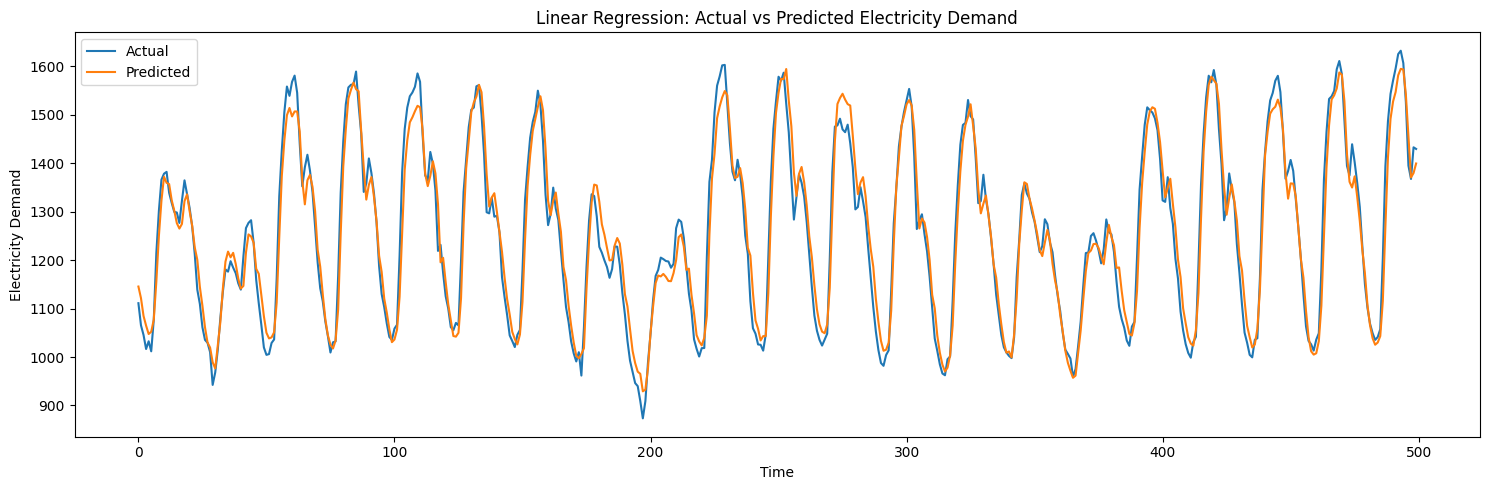

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(y_test.values[:500], label='Actual')
plt.plot(y_pred_lr[:500], label='Predicted')

plt.title('Linear Regression: Actual vs Predicted Electricity Demand')
plt.xlabel('Time')
plt.ylabel('Electricity Demand')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("MAE  :", mae_rf)
print("RMSE :", rmse_rf)
print("R²   :", r2_rf)

Random Forest Performance
MAE  : 19.362963845550663
RMSE : 27.35158421791012
R²   : 0.9783756343746114


In [ ]:
comparison = pd.DataFrame({'Model': ['Linear Regression', 'Random Forest'],'MAE': [mae_lr, mae_rf],'RMSE': [rmse_lr, rmse_rf],'R2': [r2_lr, r2_rf]})

print(comparison)

               Model        MAE       RMSE        R2
0  Linear Regression  37.024759  46.844853  0.936569
1      Random Forest  19.362964  27.351584  0.978376


In [ ]:
feature_importance = pd.DataFrame({'Feature': X_train.columns,'Importance': rf_model.feature_importances_})

feature_importance = feature_importance.sort_values(by='Importance',ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
             Feature  Importance
21      demand_lag_1    0.846887
23    demand_lag_168    0.084394
18              hour    0.044323
22     demand_lag_24    0.007631
12        Holiday_ID    0.002250
13           holiday    0.001892
24   rolling_mean_24    0.001886
19       day_of_week    0.001325
25  rolling_mean_168    0.001132
8            T2M_dav    0.000735
4            T2M_san    0.000647
20           weekend    0.000639
2            TQL_toc    0.000623
0            T2M_toc    0.000617
7            W2M_san    0.000597
11           W2M_dav    0.000541
6            TQL_san    0.000512
3            W2M_toc    0.000497
1           QV2M_toc    0.000496
17               day    0.000461
10           TQL_dav    0.000447
9           QV2M_dav    0.000393
5           QV2M_san    0.000390
16             month    0.000390
15              year    0.000253
14            school    0.000044


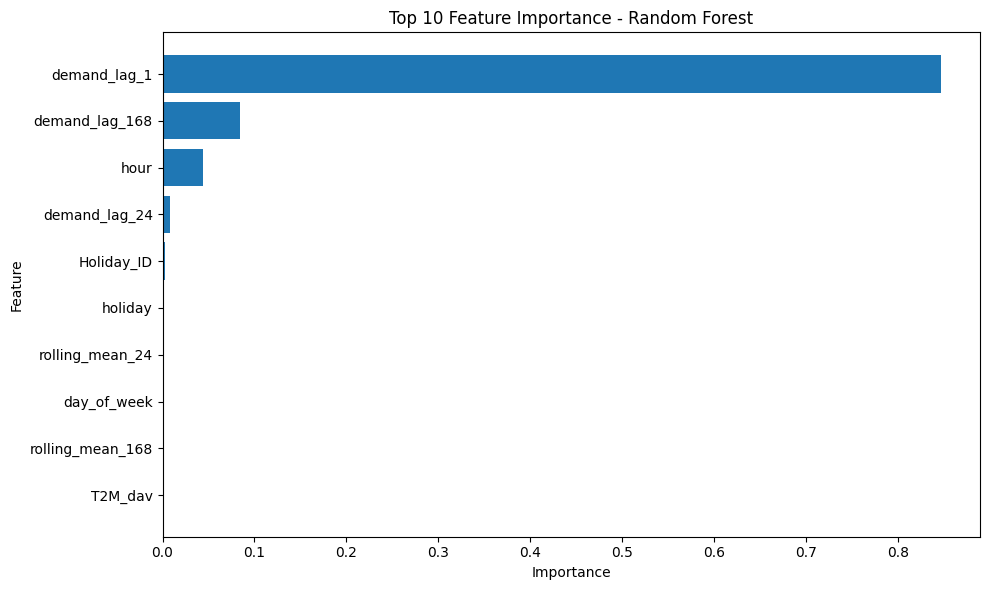

In [118]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance - Random Forest')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

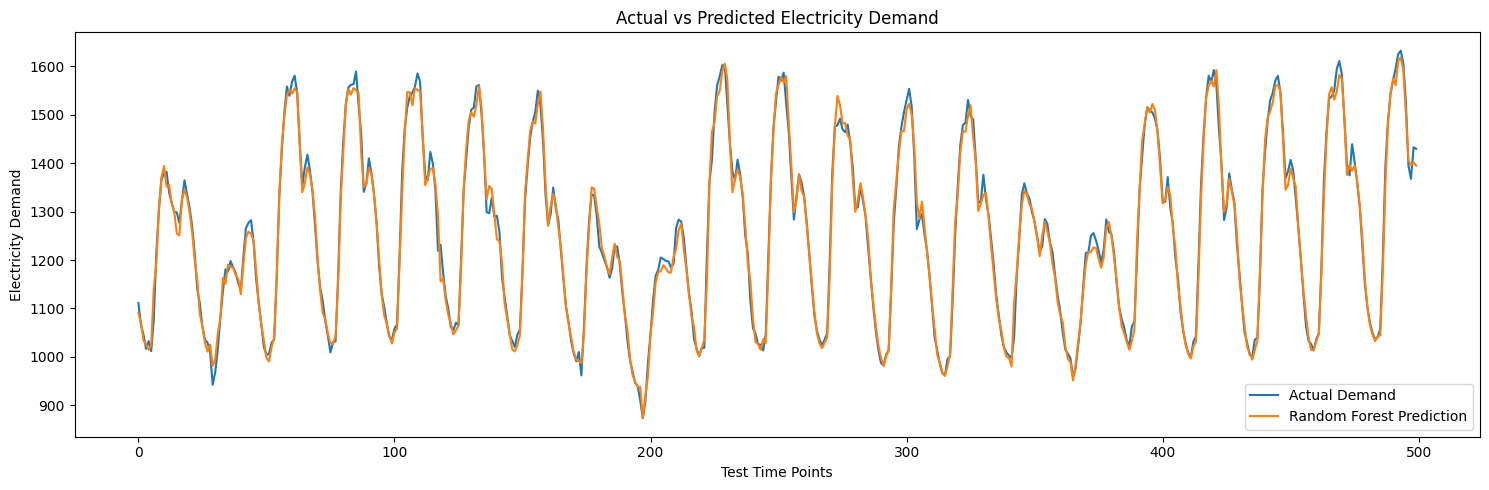

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(y_test.values[:500],label='Actual Demand')

plt.plot(y_pred_rf[:500],label='Random Forest Prediction')

plt.title('Actual vs Predicted Electricity Demand')
plt.xlabel('Test Time Points')
plt.ylabel('Electricity Demand')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
errors_rf = y_test.values - y_pred_rf

print("Prediction Error Statistics")

print("\nMean Error:", errors_rf.mean())
print("Minimum Error:", errors_rf.min())
print("Maximum Error:", errors_rf.max())
print("Mean Absolute Error:", np.abs(errors_rf).mean())

Prediction Error Statistics

Mean Error: 1.4026021181048123
Minimum Error: -234.71171900000036
Maximum Error: 245.3755629999996
Mean Absolute Error: 19.362963845550663


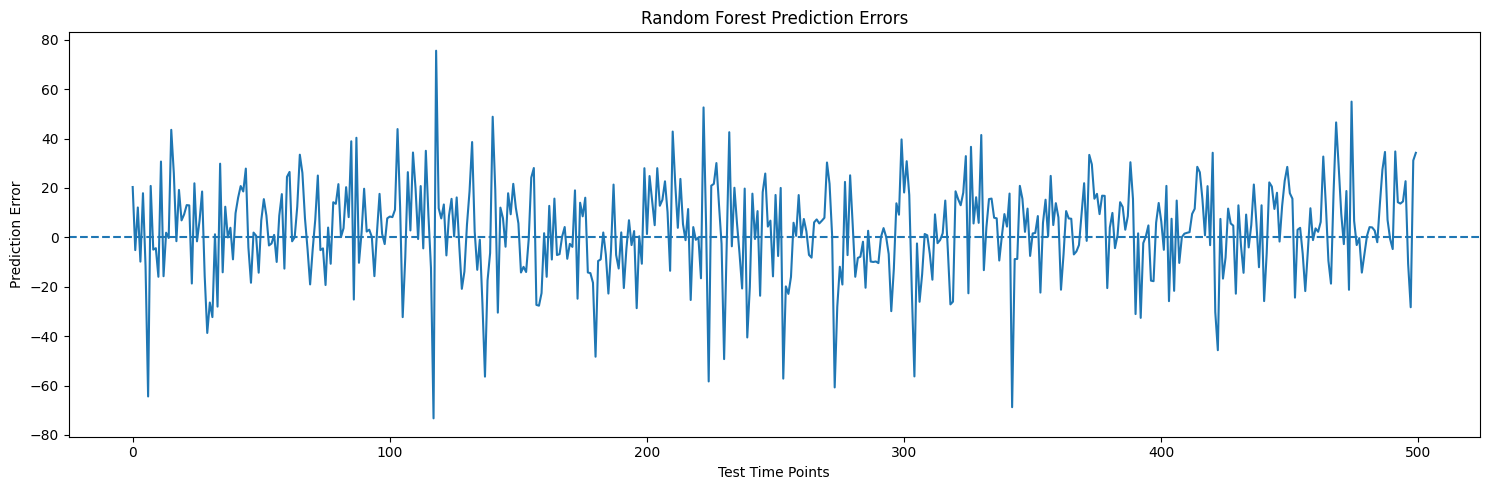

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(errors_rf[:500])

plt.axhline(y=0, linestyle='--')

plt.title('Random Forest Prediction Errors')
plt.xlabel('Test Time Points')
plt.ylabel('Prediction Error')

plt.tight_layout()
plt.show()

In [ ]:
final_comparison = pd.DataFrame({'Model': ['Linear Regression', 'Random Forest'],'MAE': [mae_lr, mae_rf],'RMSE': [rmse_lr, rmse_rf],'R2': [r2_lr, r2_rf]})
print(final_comparison)

               Model        MAE       RMSE        R2
0  Linear Regression  37.024759  46.844853  0.936569
1      Random Forest  19.362964  27.351584  0.978376


In [ ]:
import joblib
import os

save_path = '/content/drive/MyDrive/Electricity_Forecasting'

os.makedirs(save_path, exist_ok=True)

joblib.dump(rf_model, save_path + '/random_forest_model.pkl')

joblib.dump(scaler, save_path + '/feature_scaler.pkl')

print("Random Forest model saved successfully!")
print("Feature scaler saved successfully!")

Random Forest model saved successfully!
Feature scaler saved successfully!


In [ ]:
loaded_model = joblib.load('/content/drive/MyDrive/Electricity_Forecasting/random_forest_model.pkl')

loaded_scaler = joblib.load('/content/drive/MyDrive/Electricity_Forecasting/feature_scaler.pkl')

print("Model and scaler loaded successfully!")

Model and scaler loaded successfully!


In [ ]:
y_pred_loaded = loaded_model.predict(X_test)

print("First 10 original Random Forest predictions:")
print(y_pred_rf[:10])

print("\nFirst 10 loaded Random Forest predictions:")
print(y_pred_loaded[:10])

print("\nFirst 10 actual values:")
print(y_test.values[:10])

First 10 original Random Forest predictions:
[1090.82096    1070.68272725 1033.467517   1026.393393   1014.711258
 1023.53338    1141.59156254 1193.806028   1307.18686869 1370.61203167]

First 10 loaded Random Forest predictions:
[1090.82096    1070.68272725 1033.467517   1026.393393   1014.711258
 1023.53338    1141.59156254 1193.806028   1307.18686869 1370.61203167]

First 10 actual values:
[1111.1929 1065.5066 1045.5582 1016.5566 1032.5763 1011.8534 1077.1507
 1214.6239 1302.2118 1366.2126]


In [ ]:
y_pred_loaded = loaded_model.predict(X_test)

print("Predictions generated using saved model!")
print("Number of predictions:", len(y_pred_loaded))

Predictions generated using saved model!
Number of predictions: 9576


In [ ]:
def predict_electricity_demand(input_data):
    prediction = loaded_model.predict(input_data)
    return prediction

print("Prediction function updated successfully!")

Prediction function updated successfully!


In [ ]:
sample_input = X_test.iloc[[0]]

sample_prediction = predict_electricity_demand(sample_input)

print("Predicted electricity demand:", sample_prediction[0])

Predicted electricity demand: 1090.82096


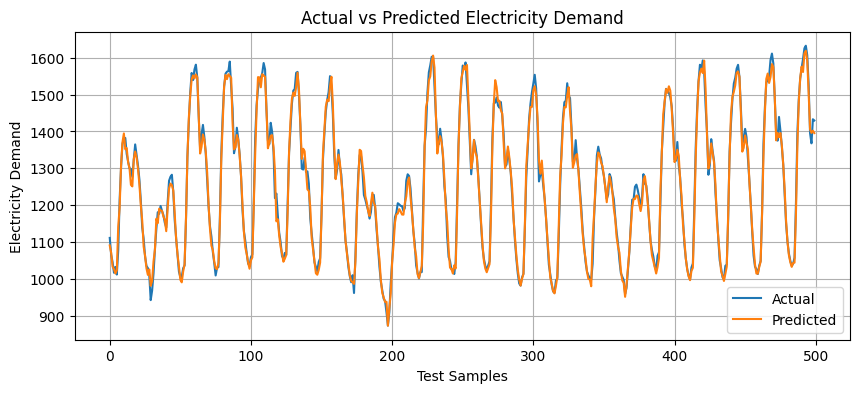

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(y_test.values[:500], label='Actual')
plt.plot(y_pred_rf[:500], label='Predicted')

plt.title('Actual vs Predicted Electricity Demand')
plt.xlabel('Test Samples')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid(True)

plt.show()

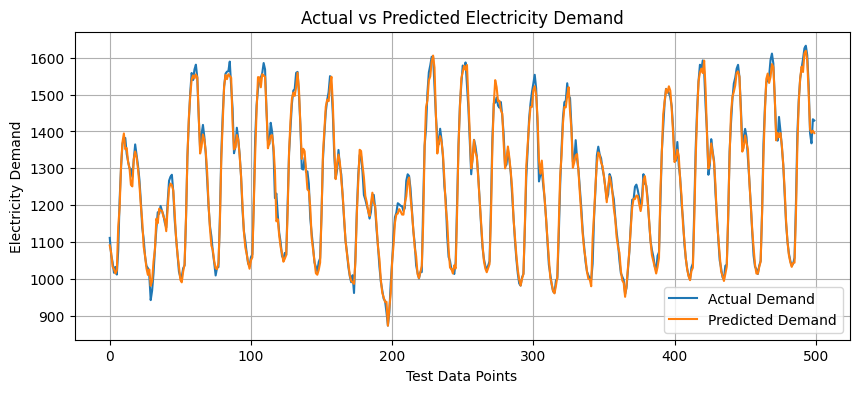

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(y_test.values[:500], label='Actual Demand')
plt.plot(y_pred_loaded[:500], label='Predicted Demand')

plt.title('Actual vs Predicted Electricity Demand')
plt.xlabel('Test Data Points')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_loaded)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_loaded))
r2_rf = r2_score(y_test, y_pred_loaded)

print("Random Forest Performance")
print("MAE  :", mae_rf)
print("RMSE :", rmse_rf)
print("R²   :", r2_rf)

Random Forest Performance
MAE  : 19.362963845550663
RMSE : 27.35158421791012
R²   : 0.9783756343746114


In [ ]:
print("Original Random Forest predictions:")
print(y_pred_rf[:10])

print("\nLoaded Random Forest predictions:")
print(y_pred_loaded[:10])

print("\nActual values:")
print(y_test.values[:10])

Original Random Forest predictions:
[1090.82096    1070.68272725 1033.467517   1026.393393   1014.711258
 1023.53338    1141.59156254 1193.806028   1307.18686869 1370.61203167]

Loaded Random Forest predictions:
[1090.82096    1070.68272725 1033.467517   1026.393393   1014.711258
 1023.53338    1141.59156254 1193.806028   1307.18686869 1370.61203167]

Actual values:
[1111.1929 1065.5066 1045.5582 1016.5566 1032.5763 1011.8534 1077.1507
 1214.6239 1302.2118 1366.2126]


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nActual demand range:")
print("Min:", y_test.min())
print("Max:", y_test.max())

print("\nPrediction range:")
print("Min:", y_pred_loaded.min())
print("Max:", y_pred_loaded.max())

X_train shape: (38304, 26)
X_test shape: (9576, 26)
y_train shape: (38304,)
y_test shape: (9576,)

Actual demand range:
Min: 816.3541
Max: 1754.882

Prediction range:
Min: 815.4059620000002
Max: 1685.7860759999994


In [ ]:
loaded_rf = joblib.load('random_forest_model.pkl')

print("Random Forest model loaded successfully!")

Random Forest model loaded successfully!


In [ ]:
y_pred_loaded = loaded_rf.predict(X_test)

print("Loaded Random Forest predictions:")
print(y_pred_loaded[:10])

print("\nActual values:")
print(y_test.values[:10])

print("\nPrediction range:")
print("Min:", y_pred_loaded.min())
print("Max:", y_pred_loaded.max())

Loaded Random Forest predictions:
[1090.82096    1070.68272725 1033.467517   1026.393393   1014.711258
 1023.53338    1141.59156254 1193.806028   1307.18686869 1370.61203167]

Actual values:
[1111.1929 1065.5066 1045.5582 1016.5566 1032.5763 1011.8534 1077.1507
 1214.6239 1302.2118 1366.2126]

Prediction range:
Min: 815.4059620000002
Max: 1685.7860759999994


In [ ]:
mae_loaded = mean_absolute_error(y_test, y_pred_loaded)
rmse_loaded = np.sqrt(mean_squared_error(y_test, y_pred_loaded))
r2_loaded = r2_score(y_test, y_pred_loaded)

print("Loaded Random Forest Performance")
print("MAE  :", mae_loaded)
print("RMSE :", rmse_loaded)
print("R²   :", r2_loaded)

Loaded Random Forest Performance
MAE  : 19.362963845550663
RMSE : 27.351584217910123
R²   : 0.9783756343746114


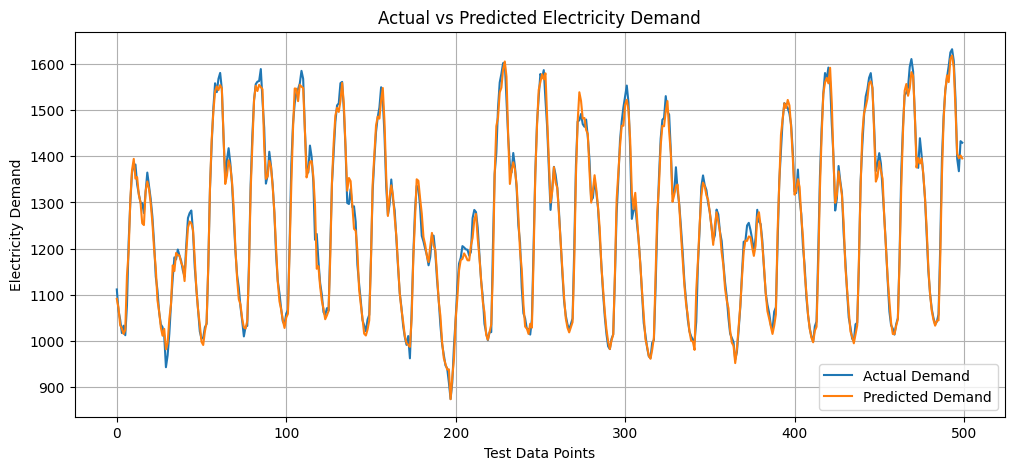

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(y_test.values[:500], label='Actual Demand')
plt.plot(y_pred_loaded[:500], label='Predicted Demand')

plt.title('Actual vs Predicted Electricity Demand')
plt.xlabel('Test Data Points')
plt.ylabel('Electricity Demand')

plt.legend()
plt.grid(True)

plt.show()

Top 15 Important Features:
             Feature  Importance
21      demand_lag_1    0.846887
23    demand_lag_168    0.084394
18              hour    0.044323
22     demand_lag_24    0.007631
12        Holiday_ID    0.002250
13           holiday    0.001892
24   rolling_mean_24    0.001886
19       day_of_week    0.001325
25  rolling_mean_168    0.001132
8            T2M_dav    0.000735
4            T2M_san    0.000647
20           weekend    0.000639
2            TQL_toc    0.000623
0            T2M_toc    0.000617
7            W2M_san    0.000597


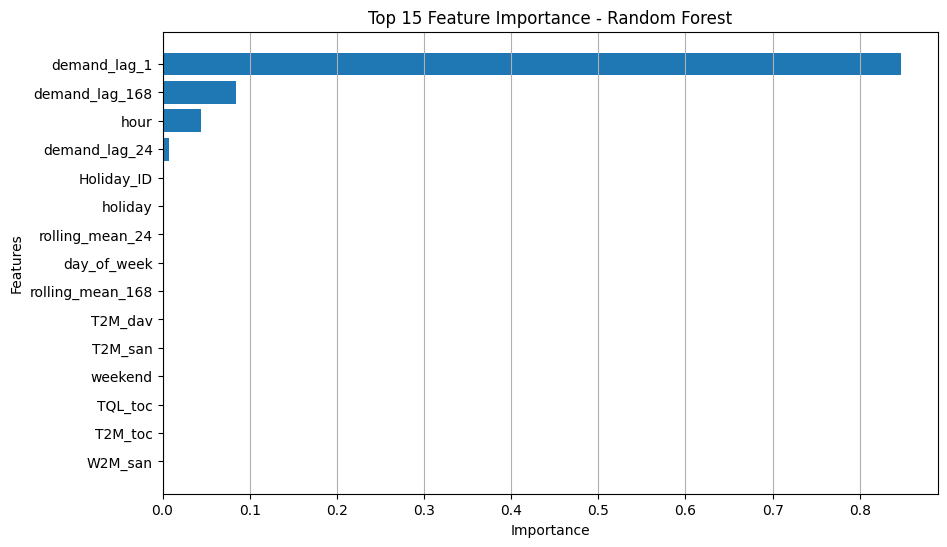

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = loaded_rf.feature_importances_

if hasattr(X_train, "columns"):
    feature_names = X_train.columns
else:
    feature_names = [f"Feature_{i}" for i in range(X_train.shape[1])]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Important Features:")
print(feature_importance.head(15))

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"].head(15)[::-1],
    feature_importance["Importance"].head(15)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 15 Feature Importance - Random Forest")
plt.grid(axis="x")

plt.show()

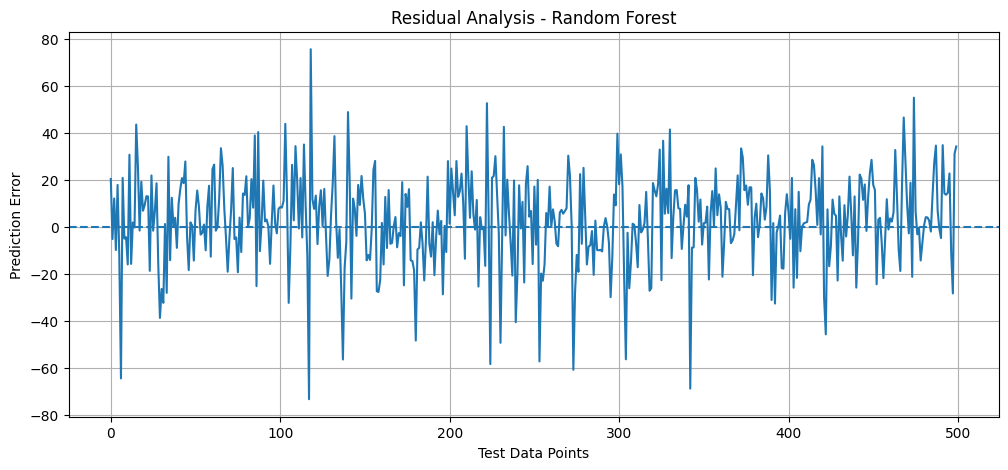

In [ ]:
residuals = y_test.values - y_pred_loaded

plt.figure(figsize=(12, 5))

plt.plot(residuals[:500])

plt.axhline(y=0, linestyle='--')

plt.title("Residual Analysis - Random Forest")
plt.xlabel("Test Data Points")
plt.ylabel("Prediction Error")

plt.grid(True)
plt.show()

In [ ]:
joblib.dump(loaded_rf, "electricity_random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import drive
import shutil
import os
import joblib
import json

drive.mount('/content/drive')

save_folder = '/content/drive/MyDrive/Electricity_Consumption_Forecasting'
os.makedirs(save_folder, exist_ok=True)

joblib.dump(loaded_rf, 'electricity_random_forest_model.pkl')

feature_names = list(X_train.columns)

with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

shutil.copy('electricity_random_forest_model.pkl', save_folder)
shutil.copy('feature_names.json', save_folder)

print("Model and feature names saved successfully!")
print("Location:", save_folder)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model and feature names saved successfully!
Location: /content/drive/MyDrive/Electricity_Consumption_Forecasting


In [ ]:
import joblib
import json
import os

save_folder = '/content/drive/MyDrive/Electricity_Consumption_Forecasting'

model_path = os.path.join(save_folder,'electricity_random_forest_model.pkl')

loaded_model = joblib.load(model_path)

feature_path = os.path.join(save_folder,'feature_names.json')

with open(feature_path, 'r') as f:
    saved_features = json.load(f)

print("Model loaded successfully!")
print("Number of features:", len(saved_features))
print("\nFeature names:")
print(saved_features)

Model loaded successfully!
Number of features: 26

Feature names:
['T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school', 'year', 'month', 'day', 'hour', 'day_of_week', 'weekend', 'demand_lag_1', 'demand_lag_24', 'demand_lag_168', 'rolling_mean_24', 'rolling_mean_168']


In [ ]:
future_data = X_test.tail(24).copy()

future_predictions = loaded_model.predict(future_data)

forecast_df = pd.DataFrame({'Forecast_Point': range(1, len(future_predictions) + 1),'Predicted_Electricity_Demand': future_predictions})

print("Future Electricity Demand Forecast:")
display(forecast_df)

Future Electricity Demand Forecast:


,Forecast_Point,Predicted_Electricity_Demand
0,1,1061.390054
1,2,1029.193860
2,3,1004.767195
3,4,998.345040
4,5,1016.789394
5,6,1007.913020
6,7,1103.059628
7,8,1231.886106
8,9,1262.883483
9,10,1261.711387


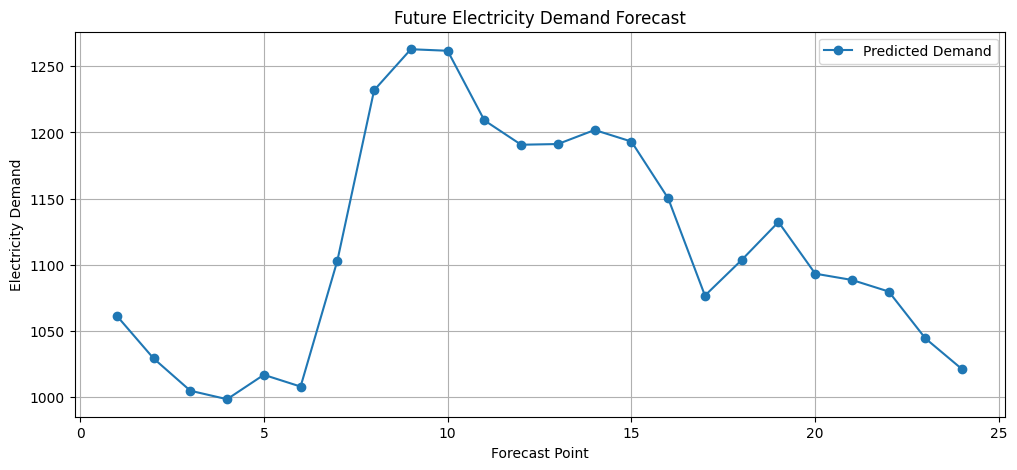

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    forecast_df['Forecast_Point'],
    forecast_df['Predicted_Electricity_Demand'],
    marker='o',
    label='Predicted Demand'
)

plt.title('Future Electricity Demand Forecast')
plt.xlabel('Forecast Point')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
forecast_path = '/content/drive/MyDrive/Electricity_Consumption_Forecasting/future_electricity_forecast.csv'

forecast_df.to_csv(forecast_path, index=False)

print("Forecast results saved successfully!")
print("Location:", forecast_path)

Forecast results saved successfully!
Location: /content/drive/MyDrive/Electricity_Consumption_Forecasting/future_electricity_forecast.csv


In [ ]:
forecast_path = '/content/drive/MyDrive/Electricity_Consumption_Forecasting/future_electricity_forecast.csv'

if os.path.exists(forecast_path):
    print("Forecast CSV saved successfully!")
    print("File size:", os.path.getsize(forecast_path), "bytes")
else:
    print("Forecast CSV not found.")

Forecast CSV saved successfully!
File size: 520 bytes


In [ ]:
print("X_train columns:")
print(list(X_train.columns))

print("\nNumber of features:", X_train.shape[1])

print("\nOriginal data columns:")
print(list(df.columns))

X_train columns:
['T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school', 'year', 'month', 'day', 'hour', 'day_of_week', 'weekend', 'demand_lag_1', 'demand_lag_24', 'demand_lag_168', 'rolling_mean_24', 'rolling_mean_168']

Number of features: 26

Original data columns:
['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school']


In [ ]:
print("Number of features:", len(X_train.columns))

print("\nFeatures used by the model:")
for i, col in enumerate(X_train.columns, 1):
    print(i, ":", col)

print("\nOriginal dataset columns:")
for i, col in enumerate(df.columns, 1):
    print(i, ":", col)

Number of features: 26

Features used by the model:
1 : T2M_toc
2 : QV2M_toc
3 : TQL_toc
4 : W2M_toc
5 : T2M_san
6 : QV2M_san
7 : TQL_san
8 : W2M_san
9 : T2M_dav
10 : QV2M_dav
11 : TQL_dav
12 : W2M_dav
13 : Holiday_ID
14 : holiday
15 : school
16 : year
17 : month
18 : day
19 : hour
20 : day_of_week
21 : weekend
22 : demand_lag_1
23 : demand_lag_24
24 : demand_lag_168
25 : rolling_mean_24
26 : rolling_mean_168

Original dataset columns:
1 : datetime
2 : nat_demand
3 : T2M_toc
4 : QV2M_toc
5 : TQL_toc
6 : W2M_toc
7 : T2M_san
8 : QV2M_san
9 : TQL_san
10 : W2M_san
11 : T2M_dav
12 : QV2M_dav
13 : TQL_dav
14 : W2M_dav
15 : Holiday_ID
16 : holiday
17 : school


In [ ]:
print("Number of features:", len(X_train.columns))

print("\nFeatures used by the model:")
for i, col in enumerate(X_train.columns, 1):
    print(i, ":", col)

Number of features: 26

Features used by the model:
1 : T2M_toc
2 : QV2M_toc
3 : TQL_toc
4 : W2M_toc
5 : T2M_san
6 : QV2M_san
7 : TQL_san
8 : W2M_san
9 : T2M_dav
10 : QV2M_dav
11 : TQL_dav
12 : W2M_dav
13 : Holiday_ID
14 : holiday
15 : school
16 : year
17 : month
18 : day
19 : hour
20 : day_of_week
21 : weekend
22 : demand_lag_1
23 : demand_lag_24
24 : demand_lag_168
25 : rolling_mean_24
26 : rolling_mean_168


In [ ]:
print("Total features:", len(X_train.columns))
print("\nFeatures required by Random Forest:\n")

for i, feature in enumerate(X_train.columns, 1):
    print(f"{i}. {feature}")

Total features: 26

Features required by Random Forest:

1. T2M_toc
2. QV2M_toc
3. TQL_toc
4. W2M_toc
5. T2M_san
6. QV2M_san
7. TQL_san
8. W2M_san
9. T2M_dav
10. QV2M_dav
11. TQL_dav
12. W2M_dav
13. Holiday_ID
14. holiday
15. school
16. year
17. month
18. day
19. hour
20. day_of_week
21. weekend
22. demand_lag_1
23. demand_lag_24
24. demand_lag_168
25. rolling_mean_24
26. rolling_mean_168


In [ ]:
final_results = pd.DataFrame({'Metric': ['MAE', 'RMSE', 'R² Score'],'Random Forest': [mae_loaded,rmse_loaded, r2_loaded ]})

print("Final Random Forest Model Performance")
display(final_results)

Final Random Forest Model Performance


,Metric,Random Forest
0,MAE,19.362964
1,RMSE,27.351584
2,R² Score,0.978376


In [ ]:
results_summary = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [mae_loaded],
    "RMSE": [rmse_loaded],
    "R2 Score": [r2_loaded]
})

display(results_summary)

,Model,MAE,RMSE,R2 Score
0,Random Forest,19.362964,27.351584,0.978376


In [ ]:
print("==========================================")
print(" ELECTRICITY CONSUMPTION FORECASTING")
print(" FINAL PROJECT SUMMARY")
print("==========================================")

print("\nModel: Random Forest Regressor")
print(f"MAE     : {mae_loaded:.4f}")
print(f"RMSE    : {rmse_loaded:.4f}")
print(f"R² Score: {r2_loaded:.4f}")

print("\nCompleted Components:")
print("✓ Data preprocessing")
print("✓ Feature engineering")
print("✓ Lag and rolling features")
print("✓ Train/Test split")
print("✓ Random Forest training")
print("✓ Model evaluation")
print("✓ Actual vs Predicted visualization")
print("✓ Feature importance analysis")
print("✓ Residual analysis")
print("✓ Model saved to Google Drive")
print("✓ Forecast generation")
print("✓ Forecast visualization")
print("✓ Forecast CSV saved")

print("\nProject Status: Core ML pipeline completed")

 ELECTRICITY CONSUMPTION FORECASTING
 FINAL PROJECT SUMMARY

Model: Random Forest Regressor
MAE     : 19.3630
RMSE    : 27.3516
R² Score: 0.9784

Completed Components:
✓ Data preprocessing
✓ Feature engineering
✓ Lag and rolling features
✓ Train/Test split
✓ Random Forest training
✓ Model evaluation
✓ Actual vs Predicted visualization
✓ Feature importance analysis
✓ Residual analysis
✓ Model saved to Google Drive
✓ Forecast generation
✓ Forecast visualization
✓ Forecast CSV saved

Project Status: Core ML pipeline completed


# Final Project Conclusion

## Project Title
Electricity Consumption Forecasting Using Machine Learning

## Conclusion

This project developed a machine learning pipeline for electricity consumption forecasting. The dataset was preprocessed and time-based features, lag features, and rolling features were created to capture electricity-demand patterns.

A Random Forest Regressor was trained using the prepared dataset and evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The final Random Forest model achieved:

- MAE: 19.36
- RMSE: 27.35
- R² Score: 0.9784

The Actual vs Predicted visualization was used to compare model predictions with actual electricity demand. Feature importance analysis was also performed to identify influential features, while residual analysis was used to examine prediction errors.

The trained Random Forest model and feature information were saved to Google Drive so that the model can be reused without retraining.

## Key Outcomes

- Data preprocessing and feature engineering were completed.
- Time-based, lag, and rolling features were created.
- A Random Forest forecasting model was developed.
- Model performance was evaluated using MAE, RMSE, and R².
- Actual vs Predicted and residual visualizations were created.
- Feature importance was analyzed.
- The trained model was saved for future use.

## Future Scope

The project can be extended by developing a proper future-date forecasting pipeline, deploying the model through a web application or dashboard, and incorporating continuously updated electricity and weather data.


# Project Methodology

## 1. Data Collection
The electricity consumption dataset was loaded and examined to understand its structure, variables, and data types.

## 2. Data Preprocessing
The dataset was cleaned and prepared for machine learning. The datetime column was converted into a proper datetime format, and relevant time-based features were extracted.

## 3. Feature Engineering
The following features were created:

- Year
- Month
- Day
- Hour
- Day of Week
- Weekend
- Lag features
- Rolling-window features

These features help the model capture temporal patterns in electricity consumption.

## 4. Data Splitting
The prepared dataset was divided into training and testing datasets. The training data was used to develop the model, while the test data was used to evaluate its performance.

## 5. Model Development
A Random Forest Regressor was trained to predict electricity demand from the engineered features.

## 6. Model Evaluation
The model was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

## 7. Visualization and Analysis
Actual and predicted electricity demand were compared using visualization. Feature importance and residual analysis were also performed to understand the model's behavior.

## 8. Model Saving
The trained Random Forest model and feature information were saved to Google Drive so that the trained model can be reused without retraining.



# Results and Discussion

## Model Performance

The Random Forest Regressor was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

| Metric | Result |
|---|---:|
| MAE | 19.36 |
| RMSE | 27.35 |
| R² Score | 0.9784 |

The results indicate that the developed Random Forest model was able to capture the patterns in the electricity consumption data effectively.

## Actual vs Predicted Demand

The Actual vs Predicted visualization was created to compare the model's predictions with the actual electricity demand values. The predicted values generally follow the pattern of the actual demand values.

## Feature Importance

Feature importance analysis was performed using the Random Forest model. The analysis showed that lag-based demand features were among the most influential features, particularly `demand_lag_1` and `demand_lag_168`.

This indicates that previous electricity demand values contain useful information for predicting future demand.

## Residual Analysis

Residual analysis was performed by calculating the difference between actual and predicted electricity demand.

The residual plot was used to examine the distribution of prediction errors around zero and identify possible patterns in the model errors.

## Forecast Results

The trained model was also used to generate electricity-demand forecast values. The forecast results were stored in a CSV file and the trained model was saved to Google Drive for future reuse.

# Future Scope

The electricity consumption forecasting system can be further improved and extended in the following ways:

1. **Real-Time Forecasting**  
   Integrate continuously updated electricity consumption data to generate real-time predictions.

2. **Advanced Machine Learning Models**  
   Compare the Random Forest model with models such as XGBoost, LightGBM, LSTM, and other time-series forecasting techniques.

3. **Weather Data Integration**  
   Incorporate real-time temperature, humidity, rainfall, and other weather information to improve forecasting.

4. **Web Application Deployment**  
   Deploy the trained model through a web application where users can enter required information and obtain electricity-demand predictions.

5. **Interactive Dashboard**  
   Develop a dashboard using tools such as Power BI or Tableau to visualize consumption trends, predictions, errors, and important features.

6. **Long-Term Forecasting**  
   Extend the system to generate daily, weekly, and monthly electricity-demand forecasts.

7. **Automated Model Updating**  
   Periodically retrain the model using newly collected electricity consumption data to maintain prediction performance.

# Electricity Consumption Forecasting Using Machine Learning

## Abstract

This project focuses on developing a machine learning-based system for electricity consumption forecasting. The dataset was processed and transformed using time-based features, lag features, and rolling-window features to capture patterns in electricity demand.

A Random Forest Regressor was developed and evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. The model achieved an MAE of 19.36, an RMSE of 27.35, and an R² Score of 0.9784 on the test data.

Actual versus predicted demand visualization, feature importance analysis, and residual analysis were performed to understand model performance. The trained model and feature information were also saved to Google Drive for future reuse.

The project demonstrates how machine learning and historical electricity-demand patterns can be used to develop an electricity consumption forecasting system.